<a href="https://colab.research.google.com/github/Pranathipilla/Netflix-Data-Cleaning-Visualization/blob/main/Life_Expectancy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df=pd.read_csv("/content/Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
df.shape
df.isnull().sum().sort_values(ascending=False)

,0
Population,652
Hepatitis B,553
GDP,448
Total expenditure,226
Alcohol,194
Income composition of resources,167
Schooling,163
thinness 1-19 years,34
thinness 5-9 years,34
BMI,34


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Country'], prefix='Country', drop_first=True)
display(df_encoded.head())

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Country_United Republic of Tanzania,Country_United States of America,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,False,False,False,False,False,False,False,False,False,False
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,False,False,False,False,False,False,False,False,False,False
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,False,False,False,False,False,False,False,False,False,False
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,False,False,False,False,False,False,False,False,False,False
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
for cols in df.columns:
  if df[cols].isnull().sum()>0:
    print(cols)

Life expectancy 
Adult Mortality
Alcohol
Hepatitis B
 BMI 
Polio
Total expenditure
Diphtheria 
GDP
Population
 thinness  1-19 years
 thinness 5-9 years
Income composition of resources
Schooling


In [ ]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [ ]:
df.to_excel("cleaned_life_expectancy.xlsx", index=False)

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
country_encoded = encoder.fit_transform(df[['Country']])
country_encoded_df = pd.DataFrame(country_encoded, columns=encoder.get_feature_names_out(['Country']))

status_encoded = encoder.fit_transform(df[['Status']])
status_encoded_df = pd.DataFrame(status_encoded, columns=encoder.get_feature_names_out(['Status']))

df_encoded = pd.concat([df.drop(['Country', 'Status'], axis=1), country_encoded_df, status_encoded_df], axis=1)
df_encoded = df_encoded.dropna()

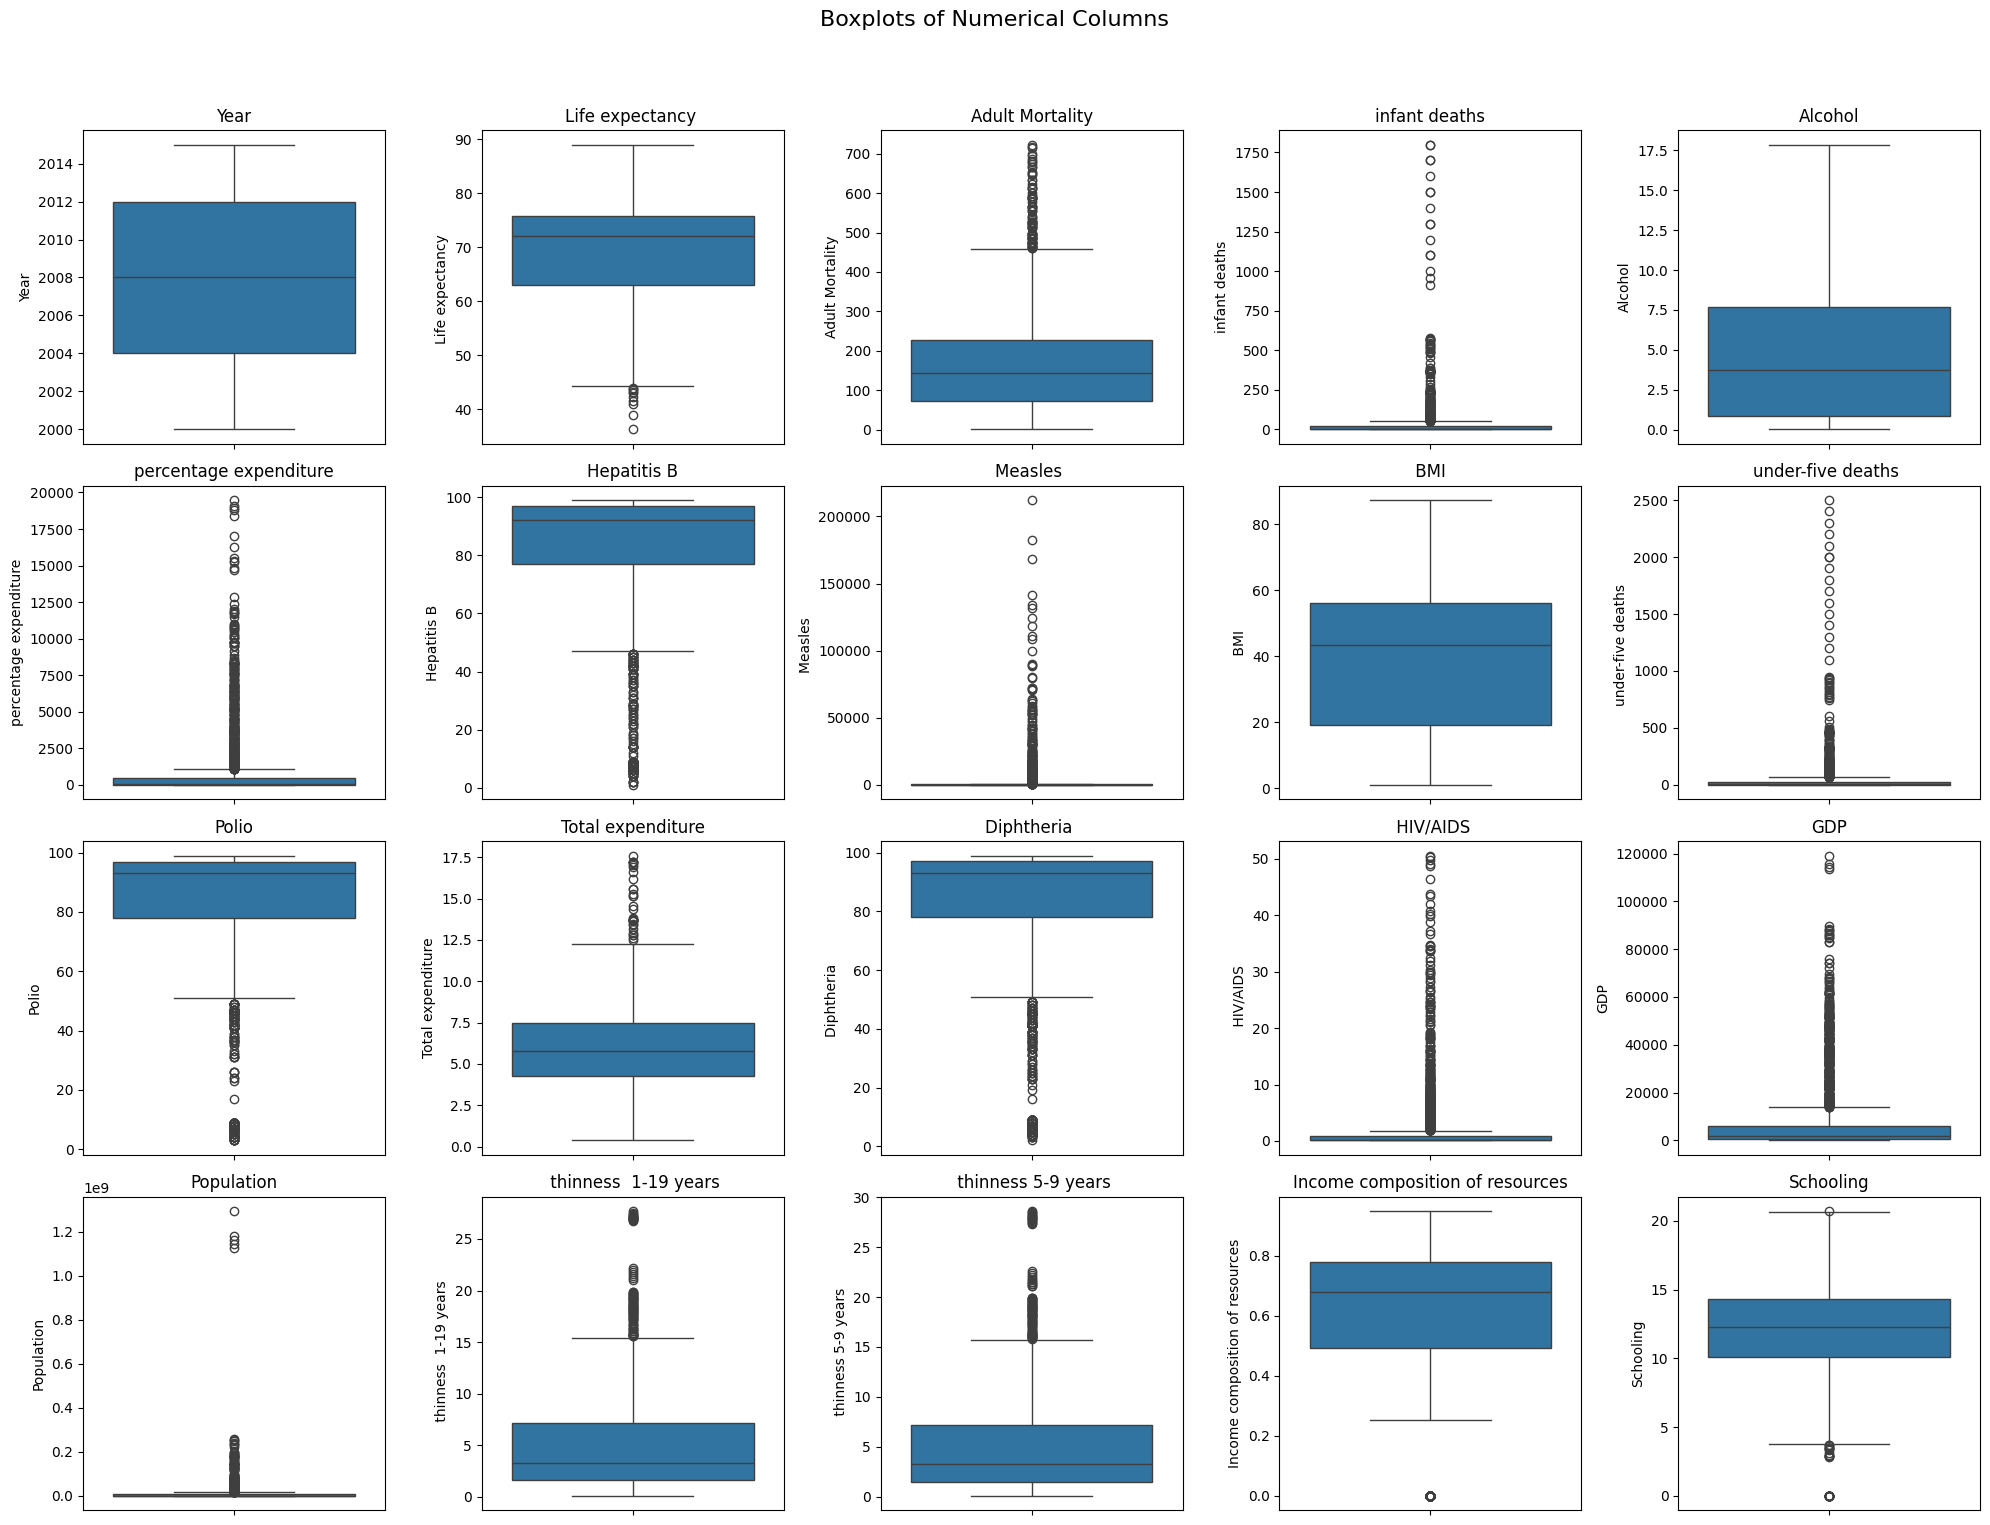

In [ ]:
numerical_cols = df.select_dtypes(include=['float64',
'int64']).columns
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Boxplots of Numerical Columns', fontsize=16)
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
  sns.boxplot(y=df[col], ax=axes[i])
  axes[i].set_title(col)
for j in range(len(numerical_cols), len(axes)):
  fig.delaxes(axes[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

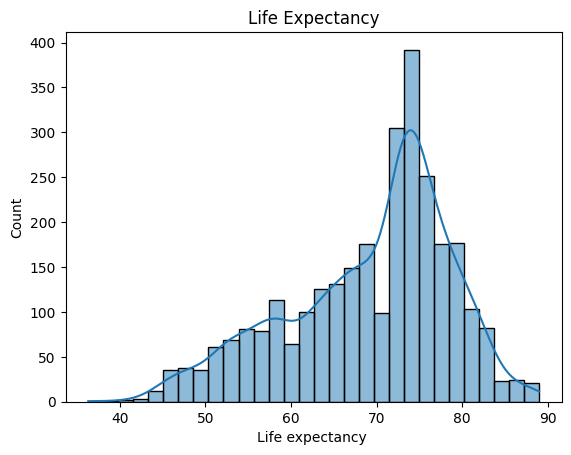

In [ ]:
sns.histplot(df['Life expectancy '], kde = True)
plt.title('Life Expectancy')
plt.show()

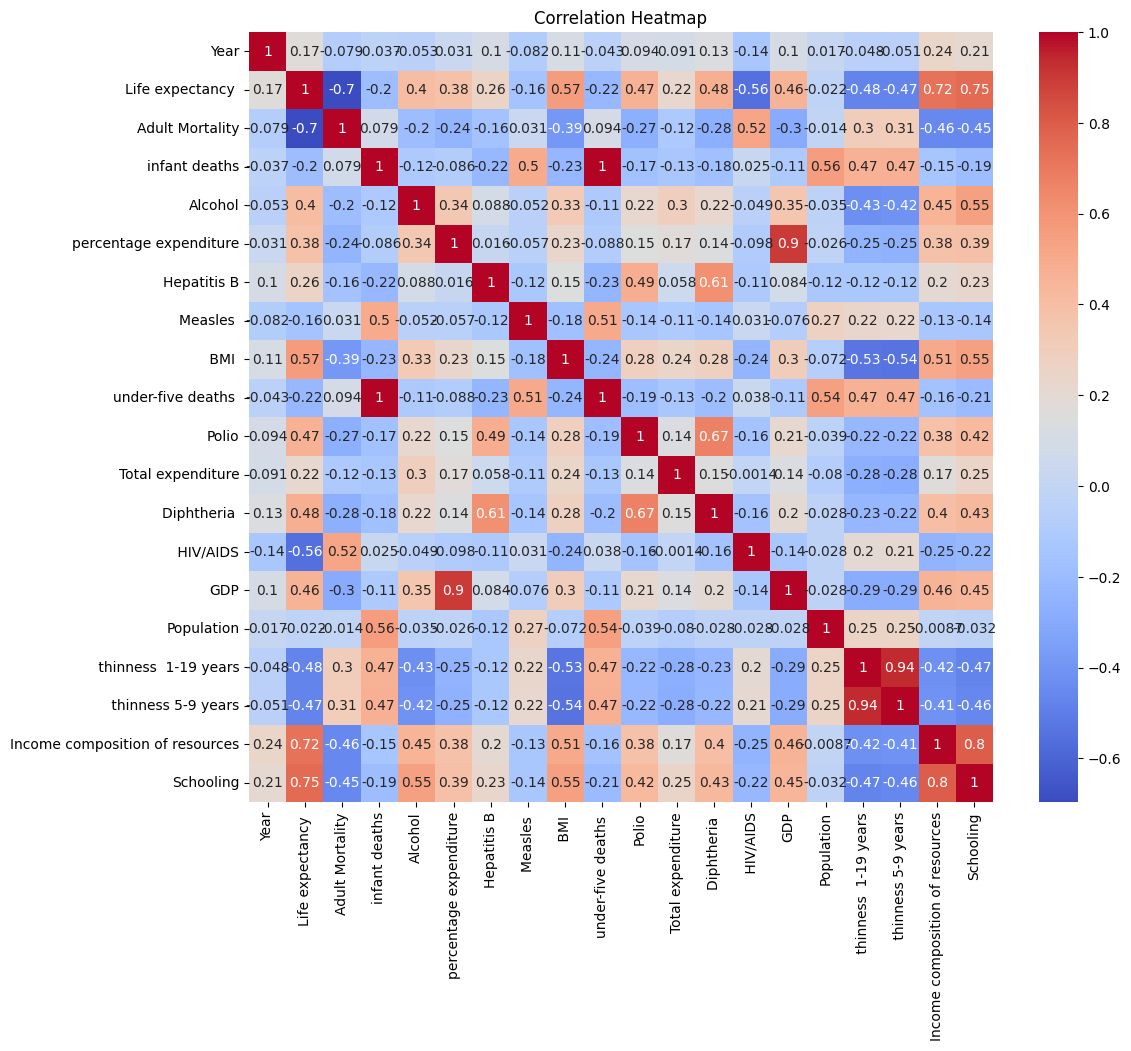

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']


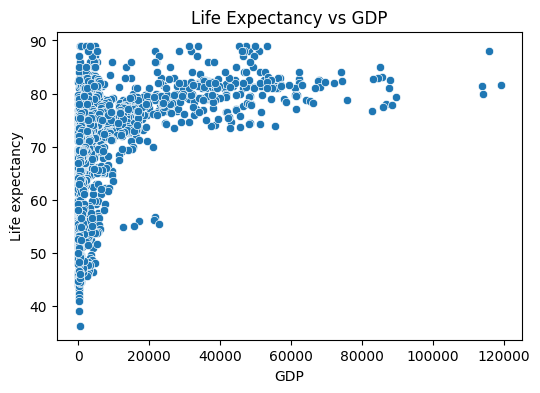

In [ ]:
print(df.columns.tolist())
df.columns=df.columns.str.strip()
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='GDP', y='Life expectancy')
plt.title('Life Expectancy vs GDP')
plt.show()

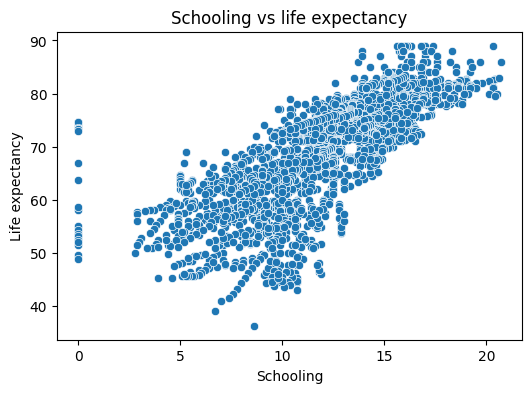

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x='Schooling', y='Life expectancy')
plt.title('Schooling vs life expectancy')
plt.show()

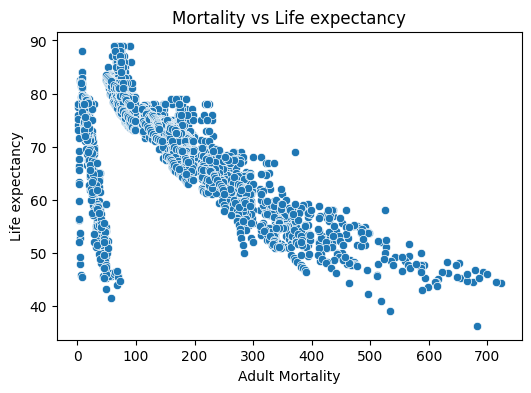

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x='Adult Mortality',y='Life expectancy')
plt.title('Mortality vs Life expectancy')
plt.show()

Text(0.5, 1.0, 'Income vs Life expectancy')

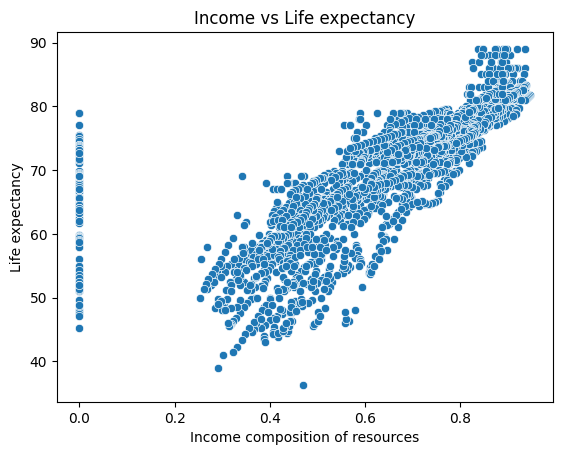

In [ ]:
sns.scatterplot(data=df,x='Income composition of resources',y='Life expectancy')
plt.title('Income vs Life expectancy')

<Axes: xlabel='HIV/AIDS', ylabel='Life expectancy'>

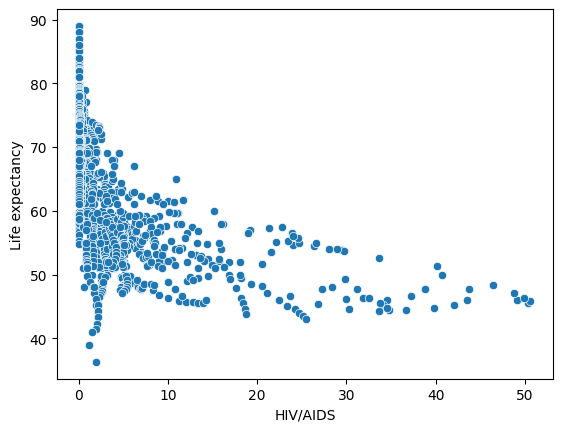

In [ ]:
sns.scatterplot(data=df,x='HIV/AIDS',y='Life expectancy')

<Axes: >

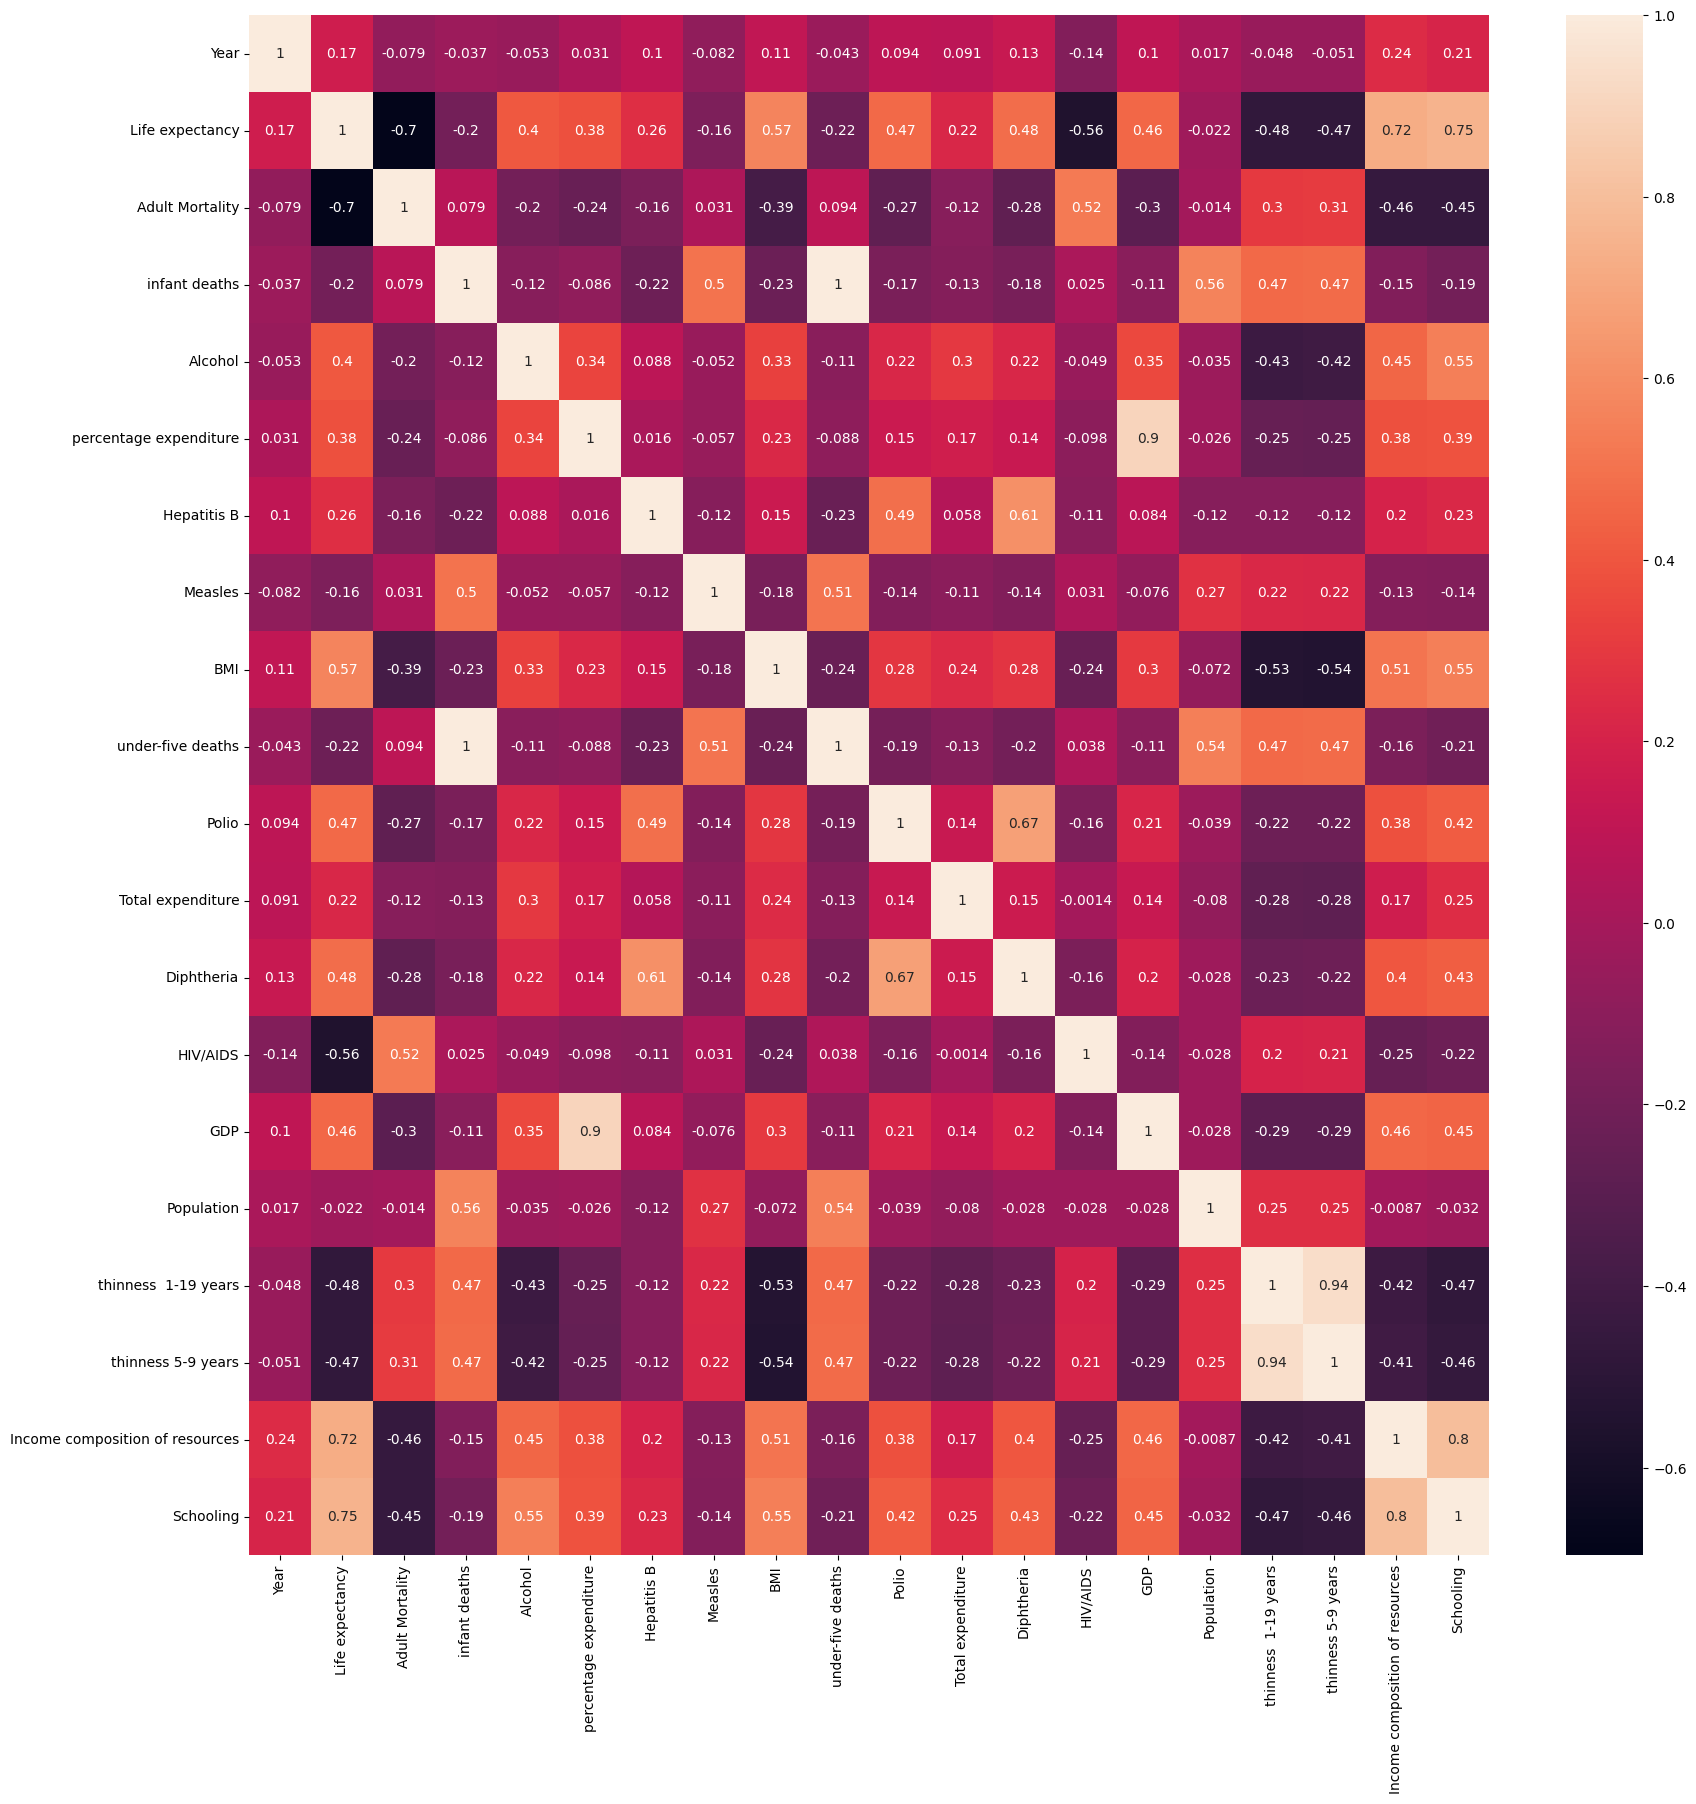

In [ ]:
plt.figure(figsize=(20,20))
numerical_df = df.select_dtypes(include=np.number)
corr_matrix=numerical_df.corr()
sns.heatmap(corr_matrix,annot=True)

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols] = df[numerical_cols].apply(lambda x: x.fillna(x.mean()))

In [ ]:
from scipy.stats import pearsonr
df.columns = df.columns.str.strip()
subset = df[['Life expectancy', 'GDP']].dropna()
corr, p_value = pearsonr(subset['Life expectancy'], subset['GDP'])
print(f"Pearson Correlation between Life Expectancy and GDP: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

Pearson Correlation between Life Expectancy and GDP: 0.4305
P-value: 7.2292e-133


In [ ]:
from scipy.stats import pearsonr
df.columns = df.columns.str.strip()
subset = df[['Life expectancy', 'Schooling']].dropna()
corr, p_value = pearsonr(subset['Life expectancy'], subset['Schooling'])
print(f"Pearson Correlation between Life Expectancy and schooling: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

Pearson Correlation between Life Expectancy and schooling: 0.7151
P-value: 0.0000e+00


In [ ]:
from scipy.stats import pearsonr
df.columns = df.columns.str.strip()
subset = df[['Life expectancy', 'Adult Mortality']].dropna()
corr, p_value = pearsonr(subset['Life expectancy'], subset['Adult Mortality'])
print(f"Pearson Correlation between Life Expectancy and Adult Mortality: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

Pearson Correlation between Life Expectancy and Adult Mortality: -0.6964
P-value: 0.0000e+00


In [ ]:
import plotly.express as px
df['Population'] = df['Population'].fillna(0)
fig =px.scatter(df,x='GDP',y='Life expectancy',size='Population',hover_name='Country',log_x=True,size_max=40)
fig.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from sklearn.ensemble import RandomForestRegressor
X = df_encoded.drop('Life expectancy ', axis=1)
y = df_encoded['Life expectancy ']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9503
RMSE: 3.5287


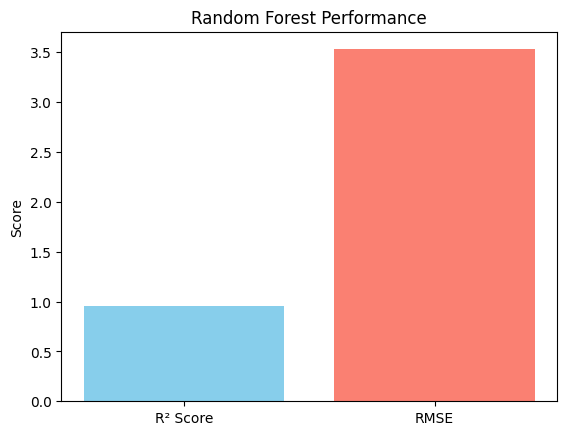

In [ ]:
import matplotlib.pyplot as plt
metrics = ['R² Score', 'RMSE']
values = [r2, rmse]
plt.bar(metrics, values, color=['skyblue', 'salmon'])
plt.ylabel('Score')
plt.title('Random Forest Performance')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
rf = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
print("R² scores for each fold:", r2_scores)
print("Mean R²:", np.mean(r2_scores))
rmse_scores = np.sqrt(-cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_squared_error'))
print("RMSE for each fold:", rmse_scores)
print("Mean RMSE:", np.mean(rmse_scores))

R² scores for each fold: [0.9496808  0.95535302 0.97021504 0.96628715 0.9456664 ]
Mean R²: 0.9574404841379831
RMSE for each fold: [1.89044829 1.97124642 1.55797768 1.62452716 1.91247747]
Mean RMSE: 1.791335403153478


Text(0.5, 1.0, 'Cross Validation scores')

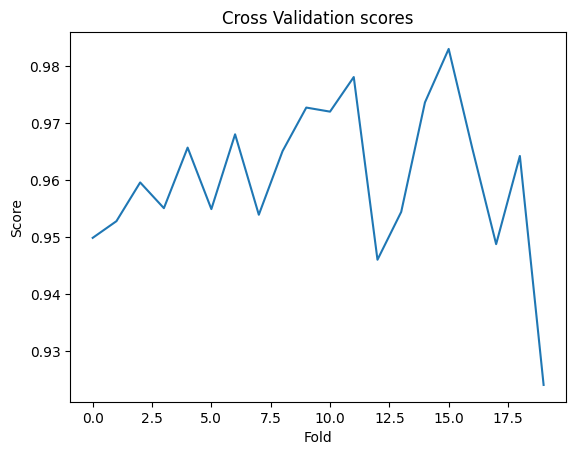

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
best_model = XGBRegressor()
kf = KFold(n_splits=20, shuffle=True, random_state=42)
cross_val = cross_val_score(best_model, X, y, cv= kf,
scoring='r2')
cross_val
plt.plot(cross_val)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title("Cross Validation scores")

In [ ]:
cross_val.mean()
cross_val.std()

np.float64(0.013037968013895288)

In [ ]:
import joblib
joblib.dump(rf, "life_expectancy_rf_model.pkl")

['life_expectancy_rf_model.pkl']

Model saved successfully!


/tmp/ipython-input-2227791948.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




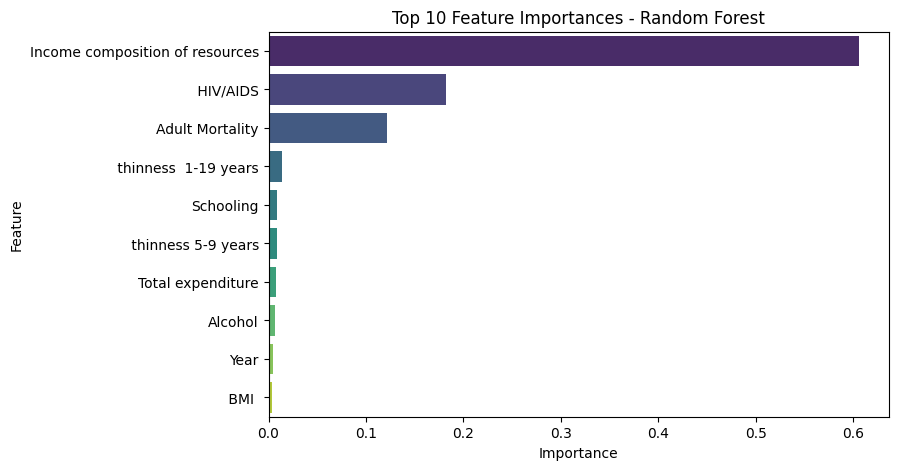

In [ ]:
from sklearn.ensemble import RandomForestRegressor
best_rf = RandomForestRegressor(random_state=42)
best_rf.fit(X_train, y_train)
joblib.dump(best_rf, "best_random_forest_model.joblib")
print("Model saved successfully!")
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


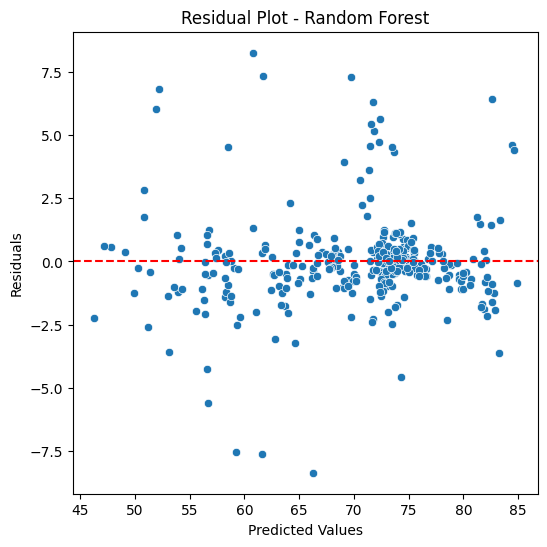

In [ ]:
y_pred = best_rf.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()

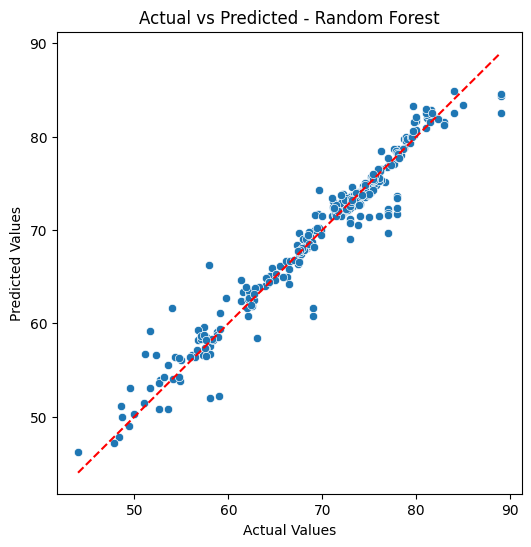

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Random Forest")
plt.show()

In [ ]:
!pip install shap

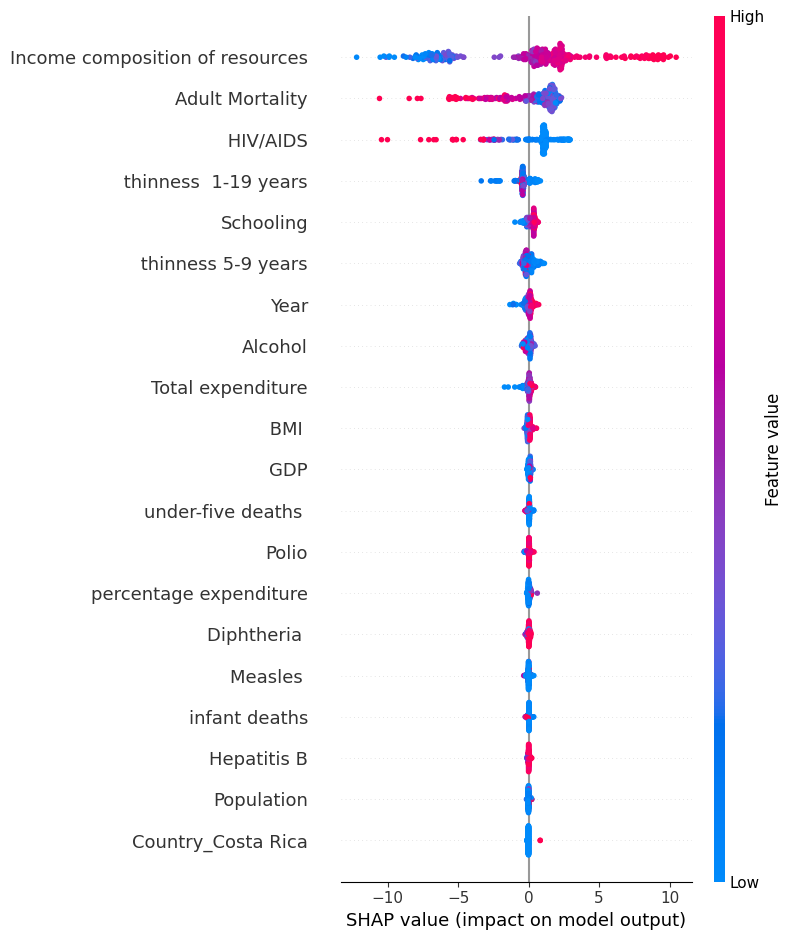

In [ ]:
import shap
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

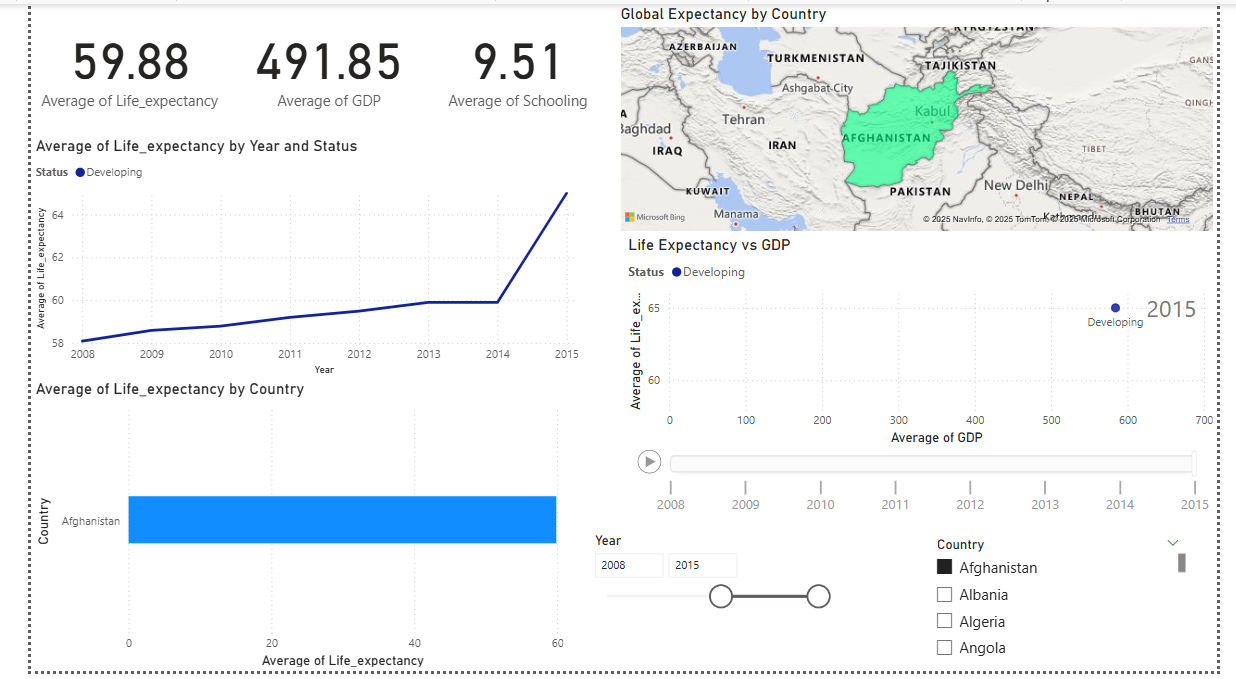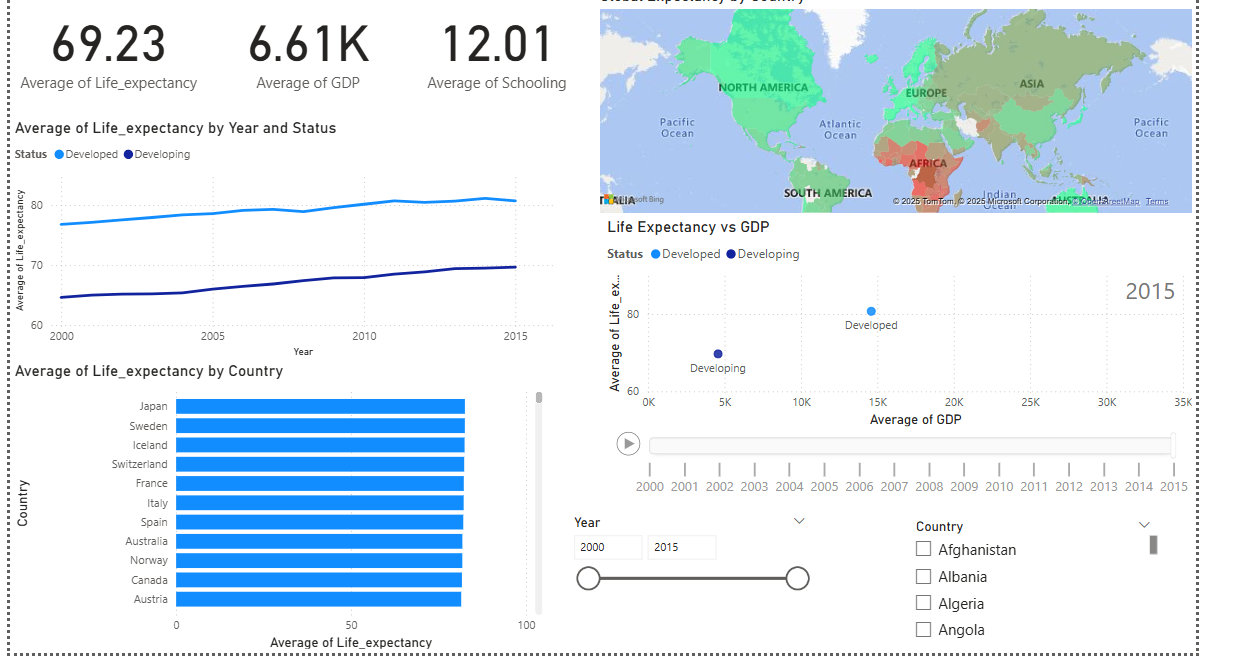

**Conclusion**


This project began with Power BI, which was instrumental in visualizing and exploring the raw data, identifying key trends and relationships that guided the subsequent model development. In this project I mainly used Random Forest to demonstrate good prediction and interpretability, it balances performance and interpretability well for this problem.


I conclude the project using SHAP visualization for key insights about life expectancy prediction model, the above graph shows Adult Mortality,HIV/AIDS has strong negative impact. The features on right increases life expectancy and features on left decreases life expectancy.


Finally , these insights suggest that countries aiming to improve life expectancy should prioritize economic growth, investment in education, and healthcare interventions targeting adult mortality reduction. Such focused strategies are likely to yield measurable improvements in population health outcomes.


